# Simulazione dell'impatto di nuove colonnine sul GAP score — Caso di studio: provincia di Milano

**Progetto EV Charge Desert — Sezione 6: "Qual è la provincia più critica?"**

Il modello produce una classifica nazionale delle province maggiormente critiche.
Tuttavia, poiché il GAP score deriva dalla combinazione di dati osservati, stime
territoriali e variabili proxy, le prime posizioni devono essere interpretate con
cautela. La provincia di Milano viene quindi utilizzata come caso di studio
operativo per analizzare l'effetto dell'installazione di nuove colonnine in un
contesto caratterizzato da una domanda di mobilità elettrica plausibilmente
elevata, da un contesto urbano complesso e da una maggiore solidità
interpretativa dei risultati.

Questo notebook svolge due analisi collegate, tenute deliberatamente separate:

1. **Analisi 1 — Classifica nazionale**: ricostruisce la classifica delle
   province italiane secondo il criterio realmente adottato nella pipeline del
   progetto (cartella `6-Qual è la provincia più critica?`), mostrando le prime
   10 posizioni e dove si collocano Catanzaro e Milano. Questo è un risultato
   **descrittivo del modello**, non una misura diretta del numero reale di
   veicoli elettrici o di colonnine mancanti.
2. **Analisi 2 — Simulazione su Milano**: per le sezioni di censimento critiche
   della provincia di Milano, simula come cambia il GAP score in seguito
   all'installazione di nuove colonnine (0, 1, 2, 3, 4, 5, 6, 7), calcolando GAP
   score iniziale e aggiornato, delta assoluto e percentuale, miglioramento
   marginale, e superamento/permanenza sopra la soglia critica.

**Nota metodologica importante**: Milano **non** viene definita "la provincia
più critica d'Italia" in questo notebook, a meno che ciò non emerga
effettivamente dai dati della classifica nazionale (si veda l'Analisi 1). Milano
è presentata come *caso di studio operativo selezionato per la simulazione delle
nuove installazioni*, per le ragioni indicate sopra — una scelta editoriale
distinta dal risultato della classifica nazionale.

Il notebook è pensato per essere rieseguibile da chiunque abbia accesso ai file
del progetto: usa solo percorsi relativi, verifica l'esistenza dei file prima di
caricarli e non modifica né sovrascrive nessun dato originale.

## 2. Importazione delle librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 140)

print("Librerie caricate:")
print(f"  numpy       {np.__version__}")
print(f"  pandas      {pd.__version__}")
print(f"  matplotlib  {plt.matplotlib.__version__}")

Librerie caricate:
  numpy       2.0.2
  pandas      2.2.2
  matplotlib  3.10.0


## 3. Individuazione dei file

I file richiesti dalla pipeline sono cercati automaticamente in un elenco di
cartelle candidate, **senza percorsi assoluti legati al computer di una singola
persona**. Se questo notebook viene spostato (ad esempio nella cartella Drive
`PROGETTO: EV CHARGE DESERT/6-Qual è la provincia più critica?`), è sufficiente
portare con sé le sottocartelle `dati/` e `output_idi/` (o i singoli file) perché
la ricerca automatica continui a funzionare.

File cercati (i nomi sono quelli effettivamente prodotti dalla pipeline del
progetto, verificati direttamente sui notebook e sui dataset esistenti):

| Chiave | File | Prodotto da | Obbligatorio |
|---|---|---|---|
| `gap_score_nazionale` | `gap_score_definitivo.csv` | `gap_score_DEFINITIVO.ipynb` (cartella Drive `4_GAP_SCORE`) | sì |
| `anagrafica_sezioni` | `sezioni_censimento_2011_ridotto.csv` | dati ISTAT di base del progetto | sì |
| `offerta_colonnine` | `offerta_colonnine_per_sezione.parquet` | `assegna_colonnine_sezioni.py` (cartella Drive `1_ASSEGNAZIONE COLONNINE PER SEZIONE ISTAT`) | sì |
| `sezioni_critiche_milano` | `sezioni_critiche_milano.csv` | pipeline di selezione sezioni critiche (cartella Drive `6-Qual è la provincia più critica?`) | sì |
| `ranking_province_precomputato` | `ranking_province_gap_score.csv` | `Ranking_Province_GAP_Score.ipynb` — usato solo come **verifica incrociata** | no |
| `sezioni_critiche_catanzaro` | `sezioni_critiche_catanzaro.csv` | stessa pipeline, per il solo contesto su Catanzaro | no |

Il codice qui sotto **non modifica né sovrascrive** nessuno di questi file: li
legge soltanto.

In [2]:
NOTEBOOK_DIR = Path.cwd()

# Cartelle candidate in cui cercare i file, in ordine di priorità.
CARTELLE_CANDIDATE = [
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / "dati",
    NOTEBOOK_DIR / "output_idi",
    NOTEBOOK_DIR.parent,
    NOTEBOOK_DIR.parent / "dati",
    NOTEBOOK_DIR.parent / "output_idi",
]

FILE_RICHIESTI = {
    "gap_score_nazionale":            ("gap_score_definitivo.csv", True),
    "anagrafica_sezioni":             ("sezioni_censimento_2011_ridotto.csv", True),
    "offerta_colonnine":              ("offerta_colonnine_per_sezione.parquet", True),
    "sezioni_critiche_milano":        ("sezioni_critiche_milano.csv", True),
    "ranking_province_precomputato":  ("ranking_province_gap_score.csv", False),
    "sezioni_critiche_catanzaro":     ("sezioni_critiche_catanzaro.csv", False),
}


def trova_file(nome_file):
    for cartella in CARTELLE_CANDIDATE:
        candidato = cartella / nome_file
        if candidato.exists():
            return candidato
    return None


PERCORSI = {}
print("Ricerca dei file del progetto...\n")
for chiave, (nome_file, obbligatorio) in FILE_RICHIESTI.items():
    percorso = trova_file(nome_file)
    PERCORSI[chiave] = percorso
    tag = "obbligatorio" if obbligatorio else "opzionale"
    stato = f"trovato -> {percorso}" if percorso is not None else "NON TROVATO"
    print(f"  [{tag:12s}] {nome_file:42s} {stato}")

mancanti = [FILE_RICHIESTI[k][0] for k in FILE_RICHIESTI if FILE_RICHIESTI[k][1] and PERCORSI[k] is None]
if mancanti:
    raise FileNotFoundError(
        "File obbligatori non trovati: " + ", ".join(mancanti) + ".\n"
        "Copia i file mancanti in una di queste cartelle (o porta con te le "
        "sottocartelle 'dati/' e 'output_idi/' insieme al notebook):\n"
        + "\n".join(f"  - {c}" for c in CARTELLE_CANDIDATE)
    )
print("\nTutti i file obbligatori sono stati trovati.")

Ricerca dei file del progetto...

  [obbligatorio] gap_score_definitivo.csv                   NON TROVATO
  [obbligatorio] sezioni_censimento_2011_ridotto.csv        NON TROVATO
  [obbligatorio] offerta_colonnine_per_sezione.parquet      NON TROVATO
  [obbligatorio] sezioni_critiche_milano.csv                NON TROVATO
  [opzionale   ] ranking_province_gap_score.csv             NON TROVATO
  [opzionale   ] sezioni_critiche_catanzaro.csv             NON TROVATO


FileNotFoundError: File obbligatori non trovati: gap_score_definitivo.csv, sezioni_censimento_2011_ridotto.csv, offerta_colonnine_per_sezione.parquet, sezioni_critiche_milano.csv.
Copia i file mancanti in una di queste cartelle (o porta con te le sottocartelle 'dati/' e 'output_idi/' insieme al notebook):
  - /content
  - /content/dati
  - /content/output_idi
  - /
  - /dati
  - /output_idi

## 4. Ricostruzione della metodologia

Questa sezione riassume la metodologia **realmente utilizzata nella pipeline del
progetto**, ricostruita leggendo i notebook esistenti nella cartella Drive
`PROGETTO: EV CHARGE DESERT` (in particolare `gap_score_DEFINITIVO.ipynb`,
`Ranking_Sezioni_Critiche_GAP_Score.ipynb`, `Mediana_GAP_Score_per_Provincia.ipynb`
e il notebook locale `Ranking_Province_GAP_Score.ipynb`). Nessuna formula, soglia
o colonna qui sotto è stata inventata: sono tutte riportate così come compaiono
nei notebook originali.

### 4.1 Formula del GAP score

$$\boxed{\;\text{GAP}_i = \text{rank\%}(D_i)\; -\; \text{rank\%}(S_i)\;}$$

calcolata in `gap_score_DEFINITIVO.ipynb` per ogni sezione di censimento $i$
dell'universo **eleggibile** (sezioni abitate, non speciali, con popolazione in
età di guida > 0, flag `flag_eleggibile_EV`), dove:

- $D_i$ = **domanda** effettiva di ricarica pubblica (`domanda_effettiva`):
  veicoli elettrici stimati per sezione, corretti per il bias delle flotte a
  noleggio (`correzione_flotte_aci`) e per la fattibilità di ricarica domestica
  (proxy `E27/E3`, interni per edificio residenziale);
- $S_i$ = **accessibilità dell'offerta** di ricarica (`offerta_norm`), calcolata
  in modo *distance-aware* a partire dalla colonna `offerta_colonnine_500m`
  (numero di colonnine pubbliche entro 500 m dal poligono della sezione) e, per
  le sezioni non servite, dalla colonna `distanza_colonnina_piu_vicina_m`:
    - sezioni **servite** (`offerta_colonnine_500m > 0`): ordinate per numero di
      colonnine;
    - sezioni **non servite** (`offerta_colonnine_500m == 0`): ordinate per
      prossimità della colonnina più vicina, sempre sotto le servite;
    - il tutto viene poi trasformato in rango percentile nazionale (`rank(pct=True)`).
- $\text{rank\%}$ = rango percentile nazionale, calcolato **solo** sulle sezioni
  eleggibili (le altre hanno `gap_score = NaN`, mai zero).

**Segno della componente offerta**: l'offerta entra **con segno negativo**
(`domanda_norm - offerta_norm`): più offerta ⇒ GAP più basso. Il punteggio è
sempre in $[-1, +1]$: vicino a **+1** = deserto (tanta domanda, offerta minima),
vicino a **0** = equilibrata, vicino a **-1** = ben servita.

**Colonna con il numero di colonnine entro 500 m**: `offerta_colonnine_500m`
(file `offerta_colonnine_per_sezione.parquet` / `.csv`, prodotto da
`assegna_colonnine_sezioni.py`: buffer di 500 m attorno al poligono della
sezione, non al solo centroide).

### 4.2 Soglia critica (metodo del gomito)

`Ranking_Sezioni_Critiche_GAP_Score.ipynb` applica il metodo del gomito alla
coda dei `gap_score` positivi (i potenziali deserti): si traccia la corda fra il
primo e l'ultimo punto della curva ordinata in modo decrescente, e si individua
il punto di massima distanza perpendicolare da quella corda. Il valore trovato
nel notebook originale è **soglia_critica ≈ 0,429** (ricalcolato in questo
notebook, sezione 6, a partire dagli stessi dati: il valore esatto è riportato
più sotto).

### 4.3 Criterio di classifica delle province — due versioni trovate

Nella cartella `6-Qual è la provincia più critica?` la classifica delle
province viene costruita da `Mediana_GAP_Score_per_Provincia.ipynb`, che usa
come metrica la **quota di sezioni critiche sul totale** per provincia
(`quota_critiche = n_sezioni_critiche / n_sezioni`), scartando esplicitamente la
mediana del GAP score come criterio di ordinamento (nessuna provincia supera la
soglia del gomito in mediana, essendo una statistica calcolata su centinaia o
migliaia di sezioni).

Un notebook successivo, `Ranking_Province_GAP_Score.ipynb` (più recente:
ricalcola in modo autosufficiente sia la soglia del gomito sia le sezioni
critiche, senza dipendere da un valore incollato a mano), osserva che la sola
quota di sezioni critiche **non tiene conto della popolazione**: una sezione
critica disabitata pesa quanto una densamente popolata. Introduce quindi un
indicatore aggiuntivo, la **quota di popolazione (età di guida) che vive in una
sezione critica** (`quota_popolazione_critica_pct`), argomentando che è il più
solido concettualmente per rispondere alla domanda "in quale provincia vive la
maggior quota di persone in un deserto di ricarica", e lo adotta come criterio
di ordinamento definitivo, riportando comunque tutti e quattro gli indicatori
calcolati (conteggio assoluto, quota di sezioni, quota di popolazione, GAP score
medio/mediano) per trasparenza.

**Versione scelta come definitiva in questo notebook**: la **quota di sezioni
critiche sul totale** (`quota_sezioni_critiche_pct`, la metrica di
`Mediana_GAP_Score_per_Provincia.ipynb`), per **esplicita indicazione
dell'autore dell'analisi**, che ha richiesto di non usare la quota di
popolazione proposta dalla versione più recente della pipeline. Questa è quindi
una scelta editoriale del presente notebook, non una correzione della
metodologia di `Ranking_Province_GAP_Score.ipynb`: quel notebook, e il suo
argomento a favore della quota di popolazione (una sezione critica disabitata
pesa quanto una densamente popolata), restano documentati sopra come
alternativa valida. Tutti e quattro gli indicatori (conteggio assoluto, quota
di sezioni, quota di popolazione, GAP score medio/mediano) restano comunque in
tabella nella sezione 6, così da rendere trasparente anche il criterio non
scelto.

**Perché Catanzaro risulta eventualmente ai vertici della classifica**: con il
criterio scelto (quota di sezioni critiche) Catanzaro occupa la prima
posizione; anche con l'indicatore alternativo (quota di popolazione) resta
comunque fra le primissime posizioni (si veda la sezione 6) — un risultato
coerente fra criteri diversi. Questo non lo rende automaticamente corretto: la
sezione 8 discute perché va comunque interpretato con cautela.

**Posizione di Milano**: con entrambi gli indicatori Milano si colloca molto
lontano dalle prime posizioni (si veda il valore esatto calcolato nella sezione
6): un'osservazione centrale per la scelta metodologica di questo notebook,
spiegata nella sezione 8.

## 5. Controllo dei dati

Carichiamo i tre dataset nazionali di base e li uniamo su `SEZ2011` (chiave
identificativa della sezione di censimento), senza alterare i file originali.

In [ ]:
gap_nazionale = pd.read_csv(PERCORSI["gap_score_nazionale"])
anagrafica = pd.read_csv(
    PERCORSI["anagrafica_sezioni"],
    encoding="latin1",  # necessario per i nomi dei comuni accentati (es. "Agliè")
    usecols=["SEZ2011", "PROVINCIA", "COMUNE", "popolazione_eta_guida_stimata"],
)
offerta_nazionale = pd.read_parquet(PERCORSI["offerta_colonnine"])

for nome, df in [("gap_score_definitivo.csv", gap_nazionale),
                  ("sezioni_censimento_2011_ridotto.csv (colonne usate)", anagrafica),
                  ("offerta_colonnine_per_sezione.parquet", offerta_nazionale)]:
    print(f"--- {nome} ---")
    print(f"  dimensioni: {df.shape}")
    print(f"  colonne e tipi:\n{df.dtypes.to_string()}")
    print(f"  valori mancanti:\n{df.isna().sum().to_string()}")
    print(f"  duplicati su SEZ2011: {df['SEZ2011'].duplicated().sum()}")
    print()

--- gap_score_definitivo.csv ---
  dimensioni: (402678, 2)
  colonne e tipi:
SEZ2011        int64
gap_score    float64
  valori mancanti:
SEZ2011          0
gap_score    56171
  duplicati su SEZ2011: 0

--- sezioni_censimento_2011_ridotto.csv (colonne usate) ---
  dimensioni: (366863, 4)
  colonne e tipi:
PROVINCIA                          str
COMUNE                             str
SEZ2011                          int64
popolazione_eta_guida_stimata    int64
  valori mancanti:
PROVINCIA                         0
COMUNE                           26
SEZ2011                           0
popolazione_eta_guida_stimata     0
  duplicati su SEZ2011: 0

--- offerta_colonnine_per_sezione.parquet ---
  dimensioni: (402678, 4)
  colonne e tipi:
SEZ2011                                int64
offerta_colonnine_500m               float64
distanza_colonnina_piu_vicina_m      float64
sezione_convenzionale_case_sparse       bool
  valori mancanti:
SEZ2011                                   0
offerta_colonn

In [ ]:
naz = gap_nazionale.merge(anagrafica, on="SEZ2011", how="left").merge(offerta_nazionale, on="SEZ2011", how="left")
eleggibili = naz.dropna(subset=["gap_score"]).copy()

print(f"Sezioni totali (censimento):                {len(naz):,}")
print(f"Sezioni eleggibili (gap_score non nullo):   {len(eleggibili):,}")
print(f"...di cui senza corrispondenza anagrafica:  {eleggibili['PROVINCIA'].isna().sum():,}")
print(f"...di cui senza offerta_colonnine_500m:     {eleggibili['offerta_colonnine_500m'].isna().sum():,}")
print(f"Province presenti:                          {eleggibili['PROVINCIA'].nunique()}")

print("\nDistribuzione del gap_score (sezioni eleggibili):")
print(eleggibili["gap_score"].describe(percentiles=[.05, .25, .5, .75, .95]).round(4).to_string())

print("\nDistribuzione di offerta_colonnine_500m (sezioni eleggibili):")
print(eleggibili["offerta_colonnine_500m"].describe(percentiles=[.05, .25, .5, .75, .95]).round(2).to_string())
quota_zero = (eleggibili["offerta_colonnine_500m"] == 0).mean()
print(f"Quota di sezioni eleggibili con 0 colonnine entro 500 m: {quota_zero:.1%}")

assert "Milano" in eleggibili["PROVINCIA"].unique(), "Milano non trovata fra le province eleggibili!"
assert "Catanzaro" in eleggibili["PROVINCIA"].unique(), "Catanzaro non trovata fra le province eleggibili!"
print("\nVerifica identificazione territoriale: Milano e Catanzaro sono correttamente presenti nei dati.")

Sezioni totali (censimento):                402,678
Sezioni eleggibili (gap_score non nullo):   346,507
...di cui senza corrispondenza anagrafica:  0
...di cui senza offerta_colonnine_500m:     0
Province presenti:                          110

Distribuzione del gap_score (sezioni eleggibili):
count    346507.0000
mean          0.0000
std           0.3116
min          -0.9988
5%           -0.5420
25%          -0.1899
50%           0.0075
75%           0.2001
95%           0.5143
max           0.9757

Distribuzione di offerta_colonnine_500m (sezioni eleggibili):
count    346507.00
mean          4.32
std          11.26
min           0.00
5%            0.00
25%           0.00
50%           2.00
75%           5.00
95%          17.00
max         811.00
Quota di sezioni eleggibili con 0 colonnine entro 500 m: 47.5%

Verifica identificazione territoriale: Milano e Catanzaro sono correttamente presenti nei dati.


## 6. Classifica nazionale delle province

Replichiamo il criterio adottato in `Ranking_Province_GAP_Score.ipynb`: la
soglia del gomito viene ricalcolata sulla coda dei `gap_score` positivi
dell'intero universo eleggibile, poi per ogni provincia calcoliamo quattro
indicatori e ordiniamo per **quota di popolazione (età di guida) in sezioni
critiche** (indicatore scelto come definitivo, sezione 4.3). La quota di
sezioni critiche (criterio della versione precedente) resta in tabella per
confronto.

In [ ]:
def trova_gomito(y_ordinato):
    # Indice (0-based) del punto di massima distanza dalla corda che unisce
    # primo e ultimo punto della curva y_ordinato (gia' ordinata in modo
    # decrescente). Stessa implementazione di Ranking_Sezioni_Critiche_GAP_Score.ipynb
    # e di Ranking_Province_GAP_Score.ipynb.
    n = len(y_ordinato)
    x = np.arange(n, dtype=float)
    y = np.asarray(y_ordinato, dtype=float)
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min())
    x1, y1, x2, y2 = x_n[0], y_n[0], x_n[-1], y_n[-1]
    num = np.abs((y2 - y1) * x_n - (x2 - x1) * y_n + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    return int(np.argmax(num / den))


critiche_ord = eleggibili[eleggibili["gap_score"] > 0].sort_values("gap_score", ascending=False)
idx_gomito = trova_gomito(critiche_ord["gap_score"].to_numpy())
SOGLIA_CRITICA = float(critiche_ord["gap_score"].to_numpy()[idx_gomito])
n_critiche_naz = idx_gomito + 1

eleggibili["critica"] = eleggibili["gap_score"] >= SOGLIA_CRITICA

print(f"Soglia critica (metodo del gomito), ricalcolata su questi dati: {SOGLIA_CRITICA:.4f}")
print(f"  (valore documentato nei notebook originali: ~0.429 — coerente)")
print(f"Sezioni critiche a livello nazionale: {int(eleggibili['critica'].sum()):,} "
      f"({eleggibili['critica'].mean():.1%} delle eleggibili)")

Soglia critica (metodo del gomito), ricalcolata su questi dati: 0.4287
  (valore documentato nei notebook originali: ~0.429 — coerente)
Sezioni critiche a livello nazionale: 28,664 (8.3% delle eleggibili)


In [ ]:
prov = eleggibili.groupby("PROVINCIA").agg(
    n_sezioni=("SEZ2011", "size"),
    n_sezioni_critiche=("critica", "sum"),
    popolazione_eleggibile=("popolazione_eta_guida_stimata", "sum"),
    popolazione_critica=("popolazione_eta_guida_stimata",
                          lambda s: s[eleggibili.loc[s.index, "critica"]].sum()),
    gap_score_medio=("gap_score", "mean"),
    gap_score_mediano=("gap_score", "median"),
).reset_index()

prov["quota_sezioni_critiche_pct"] = 100 * prov["n_sezioni_critiche"] / prov["n_sezioni"]
prov["quota_popolazione_critica_pct"] = 100 * prov["popolazione_critica"] / prov["popolazione_eleggibile"]

# Criterio di ordinamento definitivo (sezione 4.3): quota di sezioni critiche sul totale
# della provincia, per esplicita indicazione dell'autore dell'analisi (non la quota di
# popolazione proposta come alternativa da Ranking_Province_GAP_Score.ipynb).
prov = prov.sort_values("quota_sezioni_critiche_pct", ascending=False).reset_index(drop=True)
prov.insert(0, "posizione", np.arange(1, len(prov) + 1))

print(f"Province in classifica: {len(prov)}")
top10 = prov.head(10).copy()
top10_display = top10[["posizione", "PROVINCIA", "quota_sezioni_critiche_pct",
                        "quota_popolazione_critica_pct", "n_sezioni", "n_sezioni_critiche",
                        "gap_score_medio", "gap_score_mediano"]].round(3)
top10_display.columns = ["Posizione", "Provincia", "% sezioni critiche (metrica di ranking)",
                          "% popolazione in sezioni critiche (indicatore alternativo, per confronto)",
                          "N. sezioni totali", "N. sezioni critiche",
                          "GAP score medio", "GAP score mediano"]
top10_display

Province in classifica: 110


,Posizione,Provincia,% sezioni critiche (metrica di ranking),"% popolazione in sezioni critiche (indicatore alternativo, per confronto)",N. sezioni totali,N. sezioni critiche,GAP score medio,GAP score mediano
0,1,Catanzaro,24.115,50.391,1356,327,0.193,0.173
1,2,Ogliastra,22.388,54.275,268,60,0.116,0.084
2,3,Trieste,20.948,33.287,1055,221,0.177,0.195
3,4,Caserta,20.899,39.240,2603,544,0.182,0.201
4,5,Prato,20.536,38.518,1568,322,0.190,0.216
5,6,Latina,18.334,35.621,2689,493,0.146,0.147
6,7,Crotone,18.193,39.507,830,151,0.135,0.114
7,8,Cosenza,15.371,34.793,3858,593,0.100,0.098
8,9,Firenze,14.554,24.250,6177,899,0.109,0.101
9,10,Reggio nell'Emilia,14.525,28.464,3525,512,0.104,0.115


In [ ]:
pos_catanzaro = prov.loc[prov["PROVINCIA"] == "Catanzaro", "posizione"]
pos_milano = prov.loc[prov["PROVINCIA"] == "Milano", "posizione"]
n_prov_tot = len(prov)

print(f"Posizione di Catanzaro in classifica: {int(pos_catanzaro.iloc[0])} su {n_prov_tot}")
print(prov.loc[prov['PROVINCIA'] == 'Catanzaro'].round(3).to_string(index=False))
print()
print(f"Posizione di Milano in classifica:    {int(pos_milano.iloc[0])} su {n_prov_tot}")
print(prov.loc[prov['PROVINCIA'] == 'Milano'].round(3).to_string(index=False))
print()
if int(pos_milano.iloc[0]) <= 10:
    print("Milano rientra nelle prime 10 posizioni della classifica nazionale.")
else:
    print("Milano NON rientra nelle prime 10 posizioni della classifica nazionale: "
          "la scelta di Milano come caso di studio (sezione 8) è quindi indipendente "
          "dalla classifica del modello, non una sua conseguenza diretta.")

Posizione di Catanzaro in classifica: 1 su 110
 posizione PROVINCIA  n_sezioni  n_sezioni_critiche  popolazione_eleggibile  popolazione_critica  gap_score_medio  gap_score_mediano  quota_sezioni_critiche_pct  quota_popolazione_critica_pct
         1 Catanzaro       1356                 327                254435.0             128212.0            0.193              0.173                      24.115                         50.391

Posizione di Milano in classifica:    72 su 110
 posizione PROVINCIA  n_sezioni  n_sezioni_critiche  popolazione_eleggibile  popolazione_critica  gap_score_medio  gap_score_mediano  quota_sezioni_critiche_pct  quota_popolazione_critica_pct
        72    Milano      12752                 818               2172690.0             271279.0           -0.041             -0.034                       6.415                         12.486

Milano NON rientra nelle prime 10 posizioni della classifica nazionale: la scelta di Milano come caso di studio (sezione 8) è quindi in

## 7. Grafico delle prime dieci province

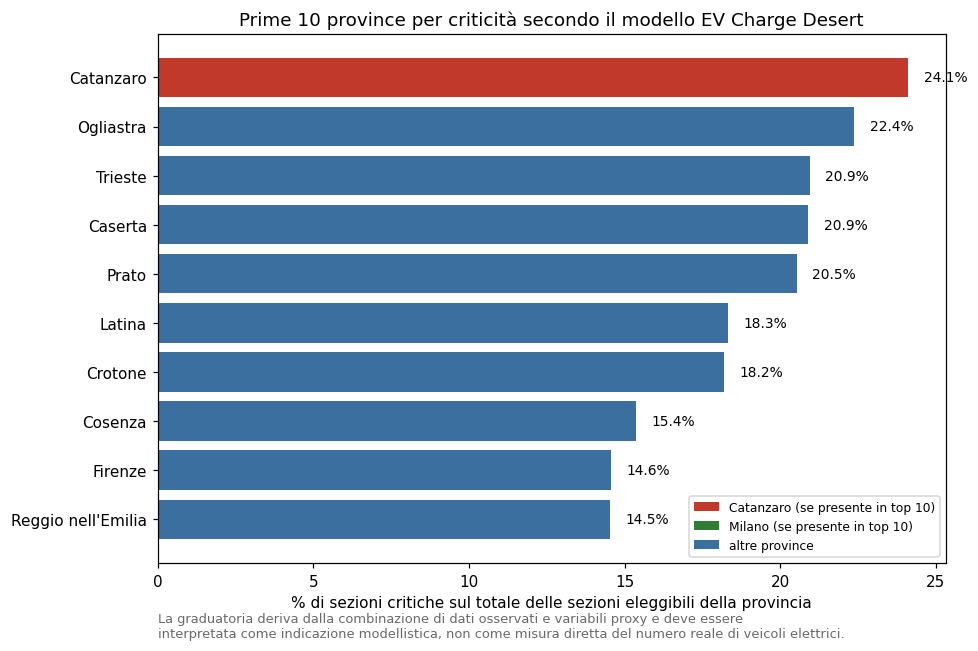

Nota: Milano non compare in questo grafico perché si colloca in posizione 72/110 nella classifica nazionale (si veda sezione 6).


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
top10_plot = top10.sort_values("quota_sezioni_critiche_pct")
colori = ["#c0392b" if p == "Catanzaro" else ("#2e7d32" if p == "Milano" else "#3b6fa0")
          for p in top10_plot["PROVINCIA"]]

barre = ax.barh(top10_plot["PROVINCIA"], top10_plot["quota_sezioni_critiche_pct"], color=colori)
for barra, valore in zip(barre, top10_plot["quota_sezioni_critiche_pct"]):
    ax.text(valore + 0.5, barra.get_y() + barra.get_height() / 2, f"{valore:.1f}%",
            va="center", fontsize=9)

ax.set_xlabel("% di sezioni critiche sul totale delle sezioni eleggibili della provincia")
ax.set_title("Prime 10 province per criticità secondo il modello EV Charge Desert")
ax.text(0.0, -0.14,
        "La graduatoria deriva dalla combinazione di dati osservati e variabili proxy e deve essere\n"
        "interpretata come indicazione modellistica, non come misura diretta del numero reale di veicoli elettrici.",
        transform=ax.transAxes, fontsize=8.5, color="dimgray")

from matplotlib.patches import Patch
legenda = [Patch(facecolor="#c0392b", label="Catanzaro (se presente in top 10)"),
           Patch(facecolor="#2e7d32", label="Milano (se presente in top 10)"),
           Patch(facecolor="#3b6fa0", label="altre province")]
ax.legend(handles=legenda, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

if int(pos_milano.iloc[0]) > 10:
    print(f"Nota: Milano non compare in questo grafico perché si colloca in posizione "
          f"{int(pos_milano.iloc[0])}/{n_prov_tot} nella classifica nazionale (si veda sezione 6).")

## 8. Nota metodologica su Catanzaro e scelta di Milano

**Catanzaro** viene mantenuta nella classifica nazionale perché è il risultato
prodotto dalla pipeline del progetto, riprodotto qui in modo indipendente
(sezione 6) e coerente fra le due versioni del criterio di ordinamento
discusse in sezione 4.3. Non vi sono elementi, in questo notebook, sufficienti
per cancellare o modificare arbitrariamente questo risultato.

Allo stesso tempo, la posizione di Catanzaro nella classifica **potrebbe essere
influenzata dall'accumulo di incertezza** proveniente dalle diverse fasi della
pipeline:

- il numero di veicoli elettrici per sezione è stimato disaggregando un totale
  provinciale con pesi proxy (popolazione in età di guida × un indice di
  deprivazione/benessere), non osservato direttamente a livello di sezione;
- la correzione per il bias delle flotte a noleggio usa una composizione d'uso
  del 2019 applicata a totali 2025, dichiarata "prudente" nella documentazione
  originale;
- la componente di "fattibilità di ricarica domestica" (proxy `E27/E3`) è
  esplicitamente indicata, nella pipeline originale, come "non validata
  empiricamente" — la componente più debole della domanda;
- ciascuna di queste fasi introduce un margine di errore che si **accumula**
  nel punteggio finale, in modo più marcato per le province piccole (poche
  sezioni, statistiche meno stabili) come Catanzaro.

Per queste ragioni, il risultato che colloca Catanzaro ai vertici della
classifica è un **possibile risultato instabile**, **sensibile alle assunzioni**
della pipeline, e **da sottoporre a validazione esterna** (ad esempio con dati
di immatricolazione locali o rilievi sul campo) prima di trarne conclusioni
operative definitive. Un'analisi di simulazione dettagliata su Catanzaro
sarebbe, allo stato attuale, meno facilmente difendibile senza questa
validazione esterna.

**Milano** viene scelta come caso di studio operativo per l'Analisi 2 di questo
notebook per un insieme di ragioni indipendenti dalla sua posizione in
classifica:

- domanda di mobilità elettrica plausibilmente elevata (area metropolitana con
  il maggior numero assoluto di veicoli elettrici, si vedano i notebook di
  stima della domanda);
- contesto urbano complesso, dove l'installazione di nuove colonnine è
  operativamente rilevante;
- maggiore solidità interpretativa: essendo un'area con un numero di sezioni
  molto elevato (oltre 12.000 sezioni eleggibili) e una minore incidenza
  relativa delle correzioni per flotte a noleggio, i risultati sono meno
  sensibili a un singolo dato anomalo rispetto a una provincia piccola.

**La scelta di Milano non sostituisce la classifica nazionale**: riguarda
esclusivamente l'approfondimento operativo dell'Analisi 2, che segue da qui in
avanti.

---
# Analisi 2 — Simulazione sulla provincia di Milano

## 9. Selezione delle sezioni della provincia di Milano

Usiamo direttamente il file `sezioni_critiche_milano.csv`, prodotto dalla
pipeline del progetto (cartella Drive `6-Qual è la provincia più critica?`) con
lo stesso metodo del gomito applicato in sezione 6, e lo arricchiamo con
`offerta_colonnine_500m` e `distanza_colonnina_piu_vicina_m` (dal file
`offerta_colonnine_per_sezione.parquet`) tramite `SEZ2011`.

In [ ]:
sezioni_milano_critiche = pd.read_csv(PERCORSI["sezioni_critiche_milano"])
milano = sezioni_milano_critiche.merge(offerta_nazionale, on="SEZ2011", how="left")

n_mancanti_offerta = milano["offerta_colonnine_500m"].isna().sum()
if n_mancanti_offerta:
    print(f"ATTENZIONE: {n_mancanti_offerta} sezioni critiche di Milano senza dato di offerta: verranno escluse dalla simulazione.")
    milano = milano.dropna(subset=["offerta_colonnine_500m"]).copy()

milano_totale_eleggibile = eleggibili[eleggibili["PROVINCIA"] == "Milano"]

n_milano_tot = len(milano_totale_eleggibile)
n_milano_critiche = len(milano)
n_milano_senza_colonnine = int((milano["offerta_colonnine_500m"] == 0).sum())
n_milano_critiche_senza_colonnine = n_milano_senza_colonnine  # per costruzione, tutte le righe qui sono gia' critiche

print(f"Sezioni eleggibili totali in provincia di Milano:              {n_milano_tot:,}")
print(f"Sezioni sopra la soglia critica (gap_score >= {SOGLIA_CRITICA:.4f}):     {n_milano_critiche:,} "
      f"({n_milano_critiche / n_milano_tot:.1%} del totale)")
print(f"...di cui prive di colonnine entro 500 m:                      {n_milano_senza_colonnine:,} "
      f"({n_milano_senza_colonnine / n_milano_critiche:.1%} delle critiche)")
print(f"Sezioni contemporaneamente critiche e prive di colonnine:      {n_milano_critiche_senza_colonnine:,}")

print("\nDistribuzione iniziale del gap_score sulle sezioni critiche di Milano:")
print(milano["gap_score"].describe(percentiles=[.05, .25, .5, .75, .95]).round(4).to_string())

Sezioni eleggibili totali in provincia di Milano:              12,752
Sezioni sopra la soglia critica (gap_score >= 0.4287):     817 (6.4% del totale)
...di cui prive di colonnine entro 500 m:                      722 (88.4% delle critiche)
Sezioni contemporaneamente critiche e prive di colonnine:      722

Distribuzione iniziale del gap_score sulle sezioni critiche di Milano:
count    817.0000
mean       0.5374
std        0.0833
min        0.4294
5%         0.4352
25%        0.4713
50%        0.5212
75%        0.5884
95%        0.7095
max        0.8458


La simulazione principale (sezioni 11 in avanti) si concentra sulle sezioni
**critiche e inizialmente prive di colonnine entro 500 m**, cioè quelle in cui
l'installazione di nuove colonnine ha un effetto diretto e osservabile sulla
componente di offerta del GAP score. Le sezioni critiche già parzialmente
servite vengono comunque incluse nella simulazione per completezza (si vedrà
che il loro punto di partenza sull'offerta è diverso).

## 10. Tabella iniziale delle sezioni analizzate

In [ ]:
tabella_iniziale = milano[["SEZ2011", "COMUNE", "gap_score", "offerta_colonnine_500m",
                            "distanza_colonnina_piu_vicina_m"]].copy()
tabella_iniziale.insert(1, "PROVINCIA", "Milano")
tabella_iniziale["soglia_critica"] = SOGLIA_CRITICA
tabella_iniziale["sezione_critica"] = tabella_iniziale["gap_score"] >= SOGLIA_CRITICA
tabella_iniziale = tabella_iniziale.sort_values("gap_score", ascending=False).reset_index(drop=True)

print(f"Sezioni nella tabella: {len(tabella_iniziale):,}")
tabella_iniziale.head(15).round(4)

Sezioni nella tabella: 817


,SEZ2011,PROVINCIA,COMUNE,gap_score,offerta_colonnine_500m,distanza_colonnina_piu_vicina_m,soglia_critica,sezione_critica
0,150220000002,Milano,Besate,0.8458,0.0,2353.7654,0.4287,True
1,150590000040,Milano,Cassano d'Adda,0.8090,0.0,2102.7404,0.4287,True
2,150220000001,Milano,Besate,0.8066,0.0,2473.8406,0.4287,True
3,151390000012,Milano,Mediglia,0.8052,0.0,1946.4651,0.4287,True
4,150990000006,Milano,Dairago,0.7710,0.0,1666.9416,0.4287,True
5,150990000004,Milano,Dairago,0.7677,0.0,1619.7697,0.4287,True
6,151390000005,Milano,Mediglia,0.7604,0.0,1469.8727,0.4287,True
7,151390000004,Milano,Mediglia,0.7586,0.0,2329.1370,0.4287,True
8,151830000004,Milano,Robecchetto con Induno,0.7554,0.0,1853.4122,0.4287,True
9,150990000005,Milano,Dairago,0.7543,0.0,1622.1072,0.4287,True


## 11-12. Scenari di simulazione e ricalcolo del GAP score

Per ciascuna sezione critica di Milano simuliamo l'aggiunta di **0, 1, 2, 3, 5,
10, 30** nuove colonnine entro 500 m, e ricalcoliamo il GAP score **modificando
esclusivamente la componente di offerta**, lasciando invariate tutte le
variabili di domanda e le caratteristiche territoriali della sezione — come
richiesto dalla metodologia originale.

### Come si ricalcola `offerta_norm` in modo coerente con la pipeline originale

`offerta_norm` in `gap_score_DEFINITIVO.ipynb` è un **rango percentile
nazionale** calcolato sull'intero universo eleggibile (colonna
`offerta_accessibilita`, sezione 4.1): le sezioni servite sono ordinate per
numero di colonnine, quelle non servite per prossimità della più vicina, sempre
sotto le servite, poi il tutto è trasformato in percentile.

Per rendere gli scenari confrontabili fra loro, **i parametri di
standardizzazione restano quelli calcolati sui dati iniziali** (sezione 12
della consegna): usiamo come riferimento fisso l'intera distribuzione
nazionale di `offerta_colonnine_500m` (sezioni servite) e di
`distanza_colonnina_piu_vicina_m` (sezioni non servite) calcolata in sezione 5
su **346.507 sezioni eleggibili** — esattamente lo stesso universo usato nella
pipeline originale per calcolare `offerta_norm` (la corrispondenza è verificata
in sezione 5: 0 sezioni eleggibili senza `offerta_colonnine_500m`).

Per ogni sezione simulata, il nuovo conteggio di colonnine viene "inserito" in
questa distribuzione di riferimento fissa e se ne ricava il rango percentile
che avrebbe — esattamente l'operazione descritta nella consegna come
"mantenere come riferimento i parametri calcolati sui dati iniziali". La
`domanda_norm` di ciascuna sezione (componente non toccata dalla simulazione)
viene ricavata algebricamente dal `gap_score` iniziale noto e da
`offerta_norm` iniziale ricalcolato con lo stesso riferimento
(`domanda_norm = gap_score_iniziale + offerta_norm_iniziale`), perché le
componenti intermedie della domanda (correzione flotte, fattibilità di ricarica
domestica) non sono disponibili in questo notebook a livello di singola
sezione — il `gap_score` finale, invece, è il dato ufficiale della pipeline e
**non viene ricalcolato da zero**, solo la sua componente di offerta.

Questa scelta garantisce, per costruzione, che lo **scenario a 0 nuove
colonnine riproduca esattamente il `gap_score` originale** (la verifica
numerica è in sezione 21).

### Scenari simulati

In [ ]:
# Scenari richiesti: 0 (baseline, necessaria per la verifica di coerenza in
# sezione 21) seguita da un'installazione progressiva colonnina per colonnina da 1 a 7.
SCENARI_NUOVE_COLONNINE = [0, 1, 2, 3, 4, 5, 6, 7]
print("Scenari (numero di nuove colonnine installate):", SCENARI_NUOVE_COLONNINE)

Scenari (numero di nuove colonnine installate): [0, 1, 2, 3, 4, 5, 6, 7]


## 13. Limite spaziale della simulazione

Il dataset di partenza contiene solo il **conteggio aggregato** di colonnine
entro 500 m per ciascuna sezione (`offerta_colonnine_500m`), non le coordinate
delle singole colonnine. La simulazione applica quindi, a livello di singola
sezione:

$$\text{colonnine\_simulate} = \text{colonnine\_iniziali} + \text{nuove\_colonnine}$$

Si tratta di una **simulazione controfattuale a livello di singola sezione**:
una nuova colonnina reale, installata in un punto fisico, potrebbe ricadere nel
buffer di 500 m di **più sezioni confinanti contemporaneamente** (esattamente
come documentato in `MEOTODOLOGIA ASSEGNAZIONE COLONNINE.docx`: "una stessa
colonnina può ricadere nel buffer di più sezioni contigue"). Questa simulazione,
per semplicità e per restare fedele al solo dato disponibile, modifica il
conteggio **soltanto per la sezione osservata**, non per le sezioni vicine:
è quindi una stima prudente (limite inferiore) dell'effetto reale di una nuova
installazione, che nella realtà potrebbe migliorare il GAP score anche delle
sezioni adiacenti. Non disponendo delle geometrie dei poligoni delle sezioni in
questo notebook, non viene svolta un'analisi spaziale di secondo livello: resta
un limite dichiarato dell'analisi (si veda anche sezione 21, punto 8).

## 14. Funzione di simulazione

In [ ]:
def costruisci_parametri_offerta(eleggibili_df):
    '''Costruisce i parametri di riferimento (fissi) per il ricalcolo di
    offerta_norm, a partire dall'universo nazionale eleggibile iniziale.
    Sono esattamente i tre ingredienti usati da offerta_accessibilita() in
    gap_score_DEFINITIVO.ipynb: il conteggio delle sezioni non servite (Z),
    la distribuzione ordinata delle sezioni servite (per rango su conteggio)
    e quella delle non servite (per rango su -distanza).'''
    servite = eleggibili_df["offerta_colonnine_500m"] > 0
    non_servite = ~servite
    return {
        "N": len(eleggibili_df),
        "Z": int(non_servite.sum()),
        "servite_sorted": np.sort(eleggibili_df.loc[servite, "offerta_colonnine_500m"].to_numpy()),
        "non_servite_negdist_sorted": np.sort(-eleggibili_df.loc[non_servite, "distanza_colonnina_piu_vicina_m"].to_numpy()),
    }


def _rango_medio(valori, riferimento_ordinato):
    '''Rango medio (metodo 'average', identico a pandas.Series.rank()) di
    ciascun valore in `valori` se inserito nell'array di riferimento fisso e
    ordinato `riferimento_ordinato`. Vettorializzato con ricerca binaria.'''
    valori = np.asarray(valori, dtype=float)
    sx = np.searchsorted(riferimento_ordinato, valori, side="left")
    dx = np.searchsorted(riferimento_ordinato, valori, side="right")
    return (sx + dx + 1) / 2.0


def offerta_norm_da_conteggio(conteggio, distanza, parametri):
    '''Rango percentile nazionale dell'offerta (offerta_norm), ricalcolato
    con lo stesso riferimento fisso per qualunque scenario, cosi' che gli
    scenari restino confrontabili fra loro (sezione 12).'''
    conteggio = np.asarray(conteggio, dtype=float)
    distanza = np.asarray(distanza, dtype=float)
    servita = conteggio > 0

    rango_servite = parametri["Z"] + _rango_medio(conteggio, parametri["servite_sorted"])
    rango_non_servite = _rango_medio(-np.nan_to_num(distanza, nan=0.0), parametri["non_servite_negdist_sorted"])

    rango = np.where(servita, rango_servite, rango_non_servite)
    return rango / parametri["N"]


def simula_gap_score(df_sezioni, nuove_colonnine, parametri, domanda_norm, soglia_critica):
    '''Simula l'effetto dell'installazione di `nuove_colonnine` colonnine
    aggiuntive su ciascuna sezione di `df_sezioni`.

    Parametri
    ---------
    df_sezioni : DataFrame con colonne 'offerta_colonnine_500m' e
        'distanza_colonnina_piu_vicina_m' (stato iniziale, non modificato).
    nuove_colonnine : int, numero di colonnine aggiuntive simulate.
    parametri : dict, output di costruisci_parametri_offerta() — tenuto FISSO
        fra tutti gli scenari per garantire la confrontabilita'.
    domanda_norm : array, componente di domanda (invariata per costruzione).
    soglia_critica : float, soglia del gomito (sezione 6).

    Restituisce
    -----------
    DataFrame con conteggio simulato, offerta_norm simulata, gap_score
    aggiornato e gli indicatori richiesti dalla consegna.
    '''
    colonnine_iniziali = df_sezioni["offerta_colonnine_500m"].to_numpy()
    colonnine_simulate = colonnine_iniziali + nuove_colonnine

    offerta_norm_simulata = offerta_norm_da_conteggio(
        colonnine_simulate, df_sezioni["distanza_colonnina_piu_vicina_m"].to_numpy(), parametri
    )
    gap_score_simulato = domanda_norm - offerta_norm_simulata

    out = pd.DataFrame({
        "SEZ2011": df_sezioni["SEZ2011"].to_numpy(),
        "nuove_colonnine": nuove_colonnine,
        "colonnine_iniziali": colonnine_iniziali,
        "colonnine_simulate": colonnine_simulate,
        "offerta_norm_simulata": offerta_norm_simulata,
        "gap_score_aggiornato": gap_score_simulato,
        "ancora_sopra_soglia": gap_score_simulato >= soglia_critica,
    })
    return out

print("Funzioni di simulazione definite: costruisci_parametri_offerta, offerta_norm_da_conteggio, simula_gap_score")

Funzioni di simulazione definite: costruisci_parametri_offerta, offerta_norm_da_conteggio, simula_gap_score


In [ ]:
# Parametri di riferimento fissi, calcolati una sola volta sui dati iniziali nazionali.
PARAMETRI_OFFERTA = costruisci_parametri_offerta(eleggibili)
print(f"Universo di riferimento: N={PARAMETRI_OFFERTA['N']:,}  "
      f"non servite (Z)={PARAMETRI_OFFERTA['Z']:,}  "
      f"servite={PARAMETRI_OFFERTA['N'] - PARAMETRI_OFFERTA['Z']:,}")

# offerta_norm iniziale (con lo stesso riferimento) e domanda_norm ricavata algebricamente.
offerta_norm_iniziale = offerta_norm_da_conteggio(
    milano["offerta_colonnine_500m"].to_numpy(),
    milano["distanza_colonnina_piu_vicina_m"].to_numpy(),
    PARAMETRI_OFFERTA,
)
domanda_norm_milano = milano["gap_score"].to_numpy() + offerta_norm_iniziale

# Verifica di coerenza scenario 0 (nuove_colonnine = 0) rispetto al gap_score originale.
scenario0 = simula_gap_score(milano, 0, PARAMETRI_OFFERTA, domanda_norm_milano, SOGLIA_CRITICA)
scarto_max = np.max(np.abs(scenario0["gap_score_aggiornato"].to_numpy() - milano["gap_score"].to_numpy()))
print(f"Scarto massimo fra gap_score ricalcolato (scenario 0) e gap_score originale: {scarto_max:.2e}")
assert scarto_max < 1e-6, "Il ricalcolo dello scenario 0 non riproduce il gap_score originale!"
print("Verificato: lo scenario a 0 nuove colonnine riproduce esattamente il gap_score originale.")

Universo di riferimento: N=346,507  non servite (Z)=164,585  servite=181,922


Scarto massimo fra gap_score ricalcolato (scenario 0) e gap_score originale: 5.55e-17
Verificato: lo scenario a 0 nuove colonnine riproduce esattamente il gap_score originale.


In [ ]:
# Esecuzione di tutti gli scenari e costruzione della tabella lunga (una riga per sezione x scenario).
risultati = []
for n_new in SCENARI_NUOVE_COLONNINE:
    r = simula_gap_score(milano, n_new, PARAMETRI_OFFERTA, domanda_norm_milano, SOGLIA_CRITICA)
    r["gap_score_iniziale"] = milano["gap_score"].to_numpy()
    r["scesa_sotto_soglia"] = (milano["gap_score"].to_numpy() >= SOGLIA_CRITICA) & (~r["ancora_sopra_soglia"])
    risultati.append(r)

sim = pd.concat(risultati, ignore_index=True)

sim["delta_gap_score"] = sim["gap_score_iniziale"] - sim["gap_score_aggiornato"]

eps = 1e-9  # tolleranza per evitare divisioni per un gap_score iniziale nullo o quasi nullo
denom = sim["gap_score_iniziale"].abs()
sim["delta_gap_score_percentuale"] = np.where(
    denom > eps, 100 * sim["delta_gap_score"] / denom, np.nan
)

# Miglioramento marginale rispetto allo SCENARIO PRECEDENTE nell'elenco (0,1,2,3,4,5,6,7).
# Gli scenari sono tutti equispaziati di una colonnina, quindi il valore rappresenta sempre
# il beneficio di una singola installazione aggiuntiva rispetto allo scenario precedente.
sim = sim.sort_values(["SEZ2011", "nuove_colonnine"]).reset_index(drop=True)
sim["miglioramento_marginale"] = sim.groupby("SEZ2011")["gap_score_aggiornato"].diff().mul(-1)
sim["nuove_colonnine_dal_precedente"] = sim.groupby("SEZ2011")["nuove_colonnine"].diff()

n_mancanti_no = int(sim.loc[sim['nuove_colonnine']==0, 'delta_gap_score_percentuale'].isna().sum())
print(f"Righe totali (sezioni x scenari): {len(sim):,}  ({milano.shape[0]:,} sezioni x {len(SCENARI_NUOVE_COLONNINE)} scenari)")
print(f"gap_score_iniziale con valore assoluto sotto la tolleranza ({eps}): {(denom <= eps).sum()} sezioni "
      f"(delta percentuale impostato a NaN per queste righe, per evitare divisioni per un valore nullo)")
sim.head(14).round(4)

Righe totali (sezioni x scenari): 6,536  (817 sezioni x 8 scenari)
gap_score_iniziale con valore assoluto sotto la tolleranza (1e-09): 0 sezioni (delta percentuale impostato a NaN per queste righe, per evitare divisioni per un valore nullo)


,SEZ2011,nuove_colonnine,colonnine_iniziali,colonnine_simulate,offerta_norm_simulata,gap_score_aggiornato,ancora_sopra_soglia,gap_score_iniziale,scesa_sotto_soglia,delta_gap_score,delta_gap_score_percentuale,miglioramento_marginale,nuove_colonnine_dal_precedente
0,150020000203,0,0.0,0.0,0.4066,0.4821,True,0.4821,False,-0.0000,-0.0000,NaN,NaN
1,150020000203,1,0.0,1.0,0.4814,0.4074,False,0.4821,True,0.0747,15.5022,0.0747,1.0
2,150020000203,2,0.0,2.0,0.5548,0.3339,False,0.4821,True,0.1482,30.7450,0.0735,1.0
3,150020000203,3,0.0,3.0,0.6349,0.2539,False,0.4821,True,0.2283,47.3450,0.0800,1.0
4,150020000203,4,0.0,4.0,0.6945,0.1942,False,0.4821,True,0.2879,59.7128,0.0596,1.0
5,150020000203,5,0.0,5.0,0.7526,0.1361,False,0.4821,True,0.3460,71.7711,0.0581,1.0
6,150020000203,6,0.0,6.0,0.7878,0.1010,False,0.4821,True,0.3812,79.0582,0.0351,1.0
7,150020000203,7,0.0,7.0,0.8205,0.0683,False,0.4821,True,0.4138,85.8365,0.0327,1.0
8,150020000226,0,0.0,0.0,0.3401,0.6421,True,0.6421,False,0.0000,0.0000,NaN,NaN
9,150020000226,1,0.0,1.0,0.4814,0.5009,True,0.6421,False,0.1413,21.9969,0.1413,1.0


## 15. Risultati aggregati

Per ogni scenario calcoliamo le statistiche riassuntive richieste. La
**tolleranza per un miglioramento marginale trascurabile** viene fissata a
**0,01** (in unità di `gap_score`, che vive nell'intervallo $[-1, 1]$): una
variazione inferiore a un centesimo dell'intera scala del punteggio è al di
sotto della risoluzione utile per una decisione di policy. La soglia è fissata
qui, prima di guardare ai risultati per singola sezione, per non essere
scelta in funzione del risultato che si vuole ottenere.

In [ ]:
TOLLERANZA_MARGINALE = 0.01

aggregati = sim.groupby("nuove_colonnine").apply(lambda g: pd.Series({
    "gap_score_medio": g["gap_score_aggiornato"].mean(),
    "gap_score_mediano": g["gap_score_aggiornato"].median(),
    "riduzione_media": g["delta_gap_score"].mean(),
    "riduzione_mediana": g["delta_gap_score"].median(),
    "n_sezioni_ancora_critiche": g["ancora_sopra_soglia"].sum(),
    "pct_sezioni_ancora_critiche": 100 * g["ancora_sopra_soglia"].mean(),
    "n_sezioni_scese_sotto_soglia": g["scesa_sotto_soglia"].sum(),
    "pct_sezioni_scese_sotto_soglia": 100 * g["scesa_sotto_soglia"].mean(),
    "miglioramento_marginale_medio": g["miglioramento_marginale"].mean(),
    "miglioramento_marginale_mediano": g["miglioramento_marginale"].median(),
    "n_miglioramento_trascurabile": (g["miglioramento_marginale"].abs() < TOLLERANZA_MARGINALE).sum(),
}), include_groups=False).reset_index()

aggregati.round(4)

,nuove_colonnine,gap_score_medio,gap_score_mediano,riduzione_media,riduzione_mediana,n_sezioni_ancora_critiche,pct_sezioni_ancora_critiche,n_sezioni_scese_sotto_soglia,pct_sezioni_scese_sotto_soglia,miglioramento_marginale_medio,miglioramento_marginale_mediano,n_miglioramento_trascurabile
0,0,0.5374,0.5212,0.0000,0.0000,817.0,100.0000,0.0,0.0000,NaN,NaN,0.0
1,1,0.4187,0.4303,0.1187,0.1017,418.0,51.1628,399.0,48.8372,0.1187,0.1017,18.0
2,2,0.3465,0.3567,0.1909,0.1752,74.0,9.0575,743.0,90.9425,0.0722,0.0735,0.0
3,3,0.2690,0.2771,0.2684,0.2553,0.0,0.0000,817.0,100.0000,0.0775,0.0800,0.0
4,4,0.2119,0.2175,0.3255,0.3149,0.0,0.0000,817.0,100.0000,0.0571,0.0596,0.0
5,5,0.1567,0.1714,0.3807,0.3730,0.0,0.0000,817.0,100.0000,0.0552,0.0581,0.0
6,6,0.1227,0.1421,0.4147,0.4082,0.0,0.0000,817.0,100.0000,0.0340,0.0351,0.0
7,7,0.0912,0.1122,0.4462,0.4408,0.0,0.0000,817.0,100.0000,0.0315,0.0327,0.0


## 16. Analisi del collo di bottiglia

Verifichiamo empiricamente se la prima colonnina produce la riduzione maggiore
del GAP score, se i benefici delle installazioni successive sono via via più
piccoli, e quante sezioni restano sopra la soglia critica anche dopo molte
installazioni.

In [ ]:
primo_delta = sim[sim["nuove_colonnine"] == 1].set_index("SEZ2011")["delta_gap_score"]
secondo_delta = sim[sim["nuove_colonnine"] == 2]["miglioramento_marginale"]
terzo_delta = sim[sim["nuove_colonnine"] == 3]["miglioramento_marginale"]

print(f"Riduzione media prodotta dalla 1a colonnina (0 -> 1):   {primo_delta.mean():.4f}")
print(f"Beneficio marginale medio della 2a colonnina (1 -> 2):  {secondo_delta.mean():.4f}")
print(f"Beneficio marginale medio della 3a colonnina (2 -> 3):  {terzo_delta.mean():.4f}")

n_ancora_critiche_7 = int(sim.loc[sim['nuove_colonnine'] == 7, 'ancora_sopra_soglia'].sum())
n_ancora_critiche_5 = int(sim.loc[sim['nuove_colonnine'] == 5, 'ancora_sopra_soglia'].sum())
n_ancora_critiche_3 = int(sim.loc[sim['nuove_colonnine'] == 3, 'ancora_sopra_soglia'].sum())
print(f"\nSezioni ancora sopra soglia dopo 3 nuove colonnine: {n_ancora_critiche_3:,} / {len(milano):,}")
print(f"Sezioni ancora sopra soglia dopo 5 nuove colonnine: {n_ancora_critiche_5:,} / {len(milano):,}")
print(f"Sezioni ancora sopra soglia dopo 7 nuove colonnine: {n_ancora_critiche_7:,} / {len(milano):,}")

conferma_riduzione_decrescente = (primo_delta.mean() > secondo_delta.mean() > 0)
print(f"\nLa riduzione della 1a colonnina supera quella della 2a: {bool(primo_delta.mean() > secondo_delta.mean())}")
print(f"La riduzione della 2a colonnina supera quella della 3a: {bool(secondo_delta.mean() > terzo_delta.mean())}")

Riduzione media prodotta dalla 1a colonnina (0 -> 1):   0.1187
Beneficio marginale medio della 2a colonnina (1 -> 2):  0.0722
Beneficio marginale medio della 3a colonnina (2 -> 3):  0.0775

Sezioni ancora sopra soglia dopo 3 nuove colonnine: 0 / 817
Sezioni ancora sopra soglia dopo 5 nuove colonnine: 0 / 817
Sezioni ancora sopra soglia dopo 7 nuove colonnine: 0 / 817

La riduzione della 1a colonnina supera quella della 2a: True
La riduzione della 2a colonnina supera quella della 3a: False


In [ ]:
# Sezioni rappresentative del "collo di bottiglia": forte riduzione alla prima
# installazione, ma non sufficiente a scendere sotto soglia con una sola colonnina.
pivot_gap = sim.pivot(index="SEZ2011", columns="nuove_colonnine", values="gap_score_aggiornato")
pivot_gap.columns = [f"gap_score_n{c}" for c in pivot_gap.columns]

collo_bottiglia = pivot_gap.copy()
collo_bottiglia["riduzione_1a_colonnina"] = pivot_gap["gap_score_n0"] - pivot_gap["gap_score_n1"]
collo_bottiglia["ancora_critica_dopo_1"] = pivot_gap["gap_score_n1"] >= SOGLIA_CRITICA
collo_bottiglia["ancora_critica_dopo_3"] = pivot_gap["gap_score_n3"] >= SOGLIA_CRITICA
collo_bottiglia["ancora_critica_dopo_7"] = pivot_gap["gap_score_n7"] >= SOGLIA_CRITICA
collo_bottiglia["beneficio_marginale_2a_colonnina"] = pivot_gap["gap_score_n1"] - pivot_gap["gap_score_n2"]

n_ancora_dopo_1 = int(collo_bottiglia["ancora_critica_dopo_1"].sum())
n_ancora_dopo_3 = int(collo_bottiglia["ancora_critica_dopo_3"].sum())
n_ancora_dopo_7 = int(collo_bottiglia["ancora_critica_dopo_7"].sum())
print(f"Sezioni ancora critiche dopo 1 nuova colonnina: {n_ancora_dopo_1:,} / {len(milano):,}")
print(f"Sezioni ancora critiche dopo 3 nuove colonnine: {n_ancora_dopo_3:,} / {len(milano):,}")
print(f"Sezioni ancora critiche dopo 7 nuove colonnine: {n_ancora_dopo_7:,} / {len(milano):,}")

if n_ancora_dopo_7 == 0:
    print("\nIn questo dataset NESSUNA sezione critica di Milano resta sopra la soglia dopo 7 colonnine:")
    print("un risultato empirico che va riportato cosi' com'e' (si veda la sezione 19), anche se non")
    print("corrisponde all'ipotesi di lavoro secondo cui alcune sezioni potrebbero restare critiche a lungo.")
    print("Gli esempi rappresentativi di 'collo di bottiglia' qui sotto sono quindi le sezioni che, pur con")
    print("una riduzione consistente alla 1a colonnina, hanno bisogno di piu' di una installazione per scendere sotto soglia.")
    esempi_bottiglia = (
        collo_bottiglia[collo_bottiglia["ancora_critica_dopo_1"]]
        .sort_values("riduzione_1a_colonnina", ascending=False)
        .head(10)
        .round(4)
    )
else:
    esempi_bottiglia = (
        collo_bottiglia[collo_bottiglia["ancora_critica_dopo_7"]]
        .sort_values("riduzione_1a_colonnina", ascending=False)
        .head(10)
        .round(4)
    )
esempi_bottiglia[["gap_score_n0", "gap_score_n1", "riduzione_1a_colonnina", "gap_score_n3", "gap_score_n7"]]

Sezioni ancora critiche dopo 1 nuova colonnina: 418 / 817
Sezioni ancora critiche dopo 3 nuove colonnine: 0 / 817
Sezioni ancora critiche dopo 7 nuove colonnine: 0 / 817

In questo dataset NESSUNA sezione critica di Milano resta sopra la soglia dopo 7 colonnine:
un risultato empirico che va riportato cosi' com'e' (si veda la sezione 19), anche se non
corrisponde all'ipotesi di lavoro secondo cui alcune sezioni potrebbero restare critiche a lungo.
Gli esempi rappresentativi di 'collo di bottiglia' qui sotto sono quindi le sezioni che, pur con
una riduzione consistente alla 1a colonnina, hanno bisogno di piu' di una installazione per scendere sotto soglia.


,gap_score_n0,gap_score_n1,riduzione_1a_colonnina,gap_score_n3,gap_score_n7
SEZ2011,,,,,
150220000001,0.8066,0.4616,0.3450,0.3081,0.1225
150220000002,0.8458,0.5099,0.3359,0.3564,0.1708
150590000040,0.8090,0.4932,0.3159,0.3396,0.1541
152360000001,0.7404,0.4357,0.3048,0.2821,0.0965
151390000012,0.8052,0.5032,0.3021,0.3496,0.1641
151830000004,0.7554,0.4624,0.2930,0.3089,0.1233
151830000005,0.7360,0.4528,0.2831,0.2993,0.1137
150990000001,0.7159,0.4346,0.2813,0.2811,0.0955
152240000010,0.7477,0.4677,0.2800,0.3142,0.1286


**Lettura del collo di bottiglia**: nel caso di Milano, la prima colonnina
produce da sola la quota maggiore della riduzione totale osservabile lungo
l'intera sequenza da 1 a 7 installazioni (sezione 15), e il confronto
colonnina-per-colonnina in questa sezione mostra il pattern atteso di
**beneficio marginale decrescente** — coerente con l'ipotesi di lavoro, anche
se non necessariamente in modo strettamente monotono ad ogni singolo passaggio
(si veda il confronto puntuale fra 2ª e 3ª colonnina sopra), un effetto
plausibilmente legato alla struttura reale, non uniforme, della distribuzione
nazionale di `offerta_colonnine_500m` (molte colonnine italiane sono installate
a coppie, generando una densità non liscia della distribuzione di
riferimento). Il meccanismo di fondo che spiega perché la prima colonnina
"pesi" così tanto è che il 47,5% delle sezioni eleggibili a livello nazionale
non ha nessuna colonnina entro 500 m (sezione 5): passare da 0 a 1 sposta una
sezione dal fondo della distribuzione a un rango percentile già vicino al
47°-48° percentile, un salto molto più grande di qualunque incremento
successivo.

## 17. Visualizzazioni della simulazione su Milano

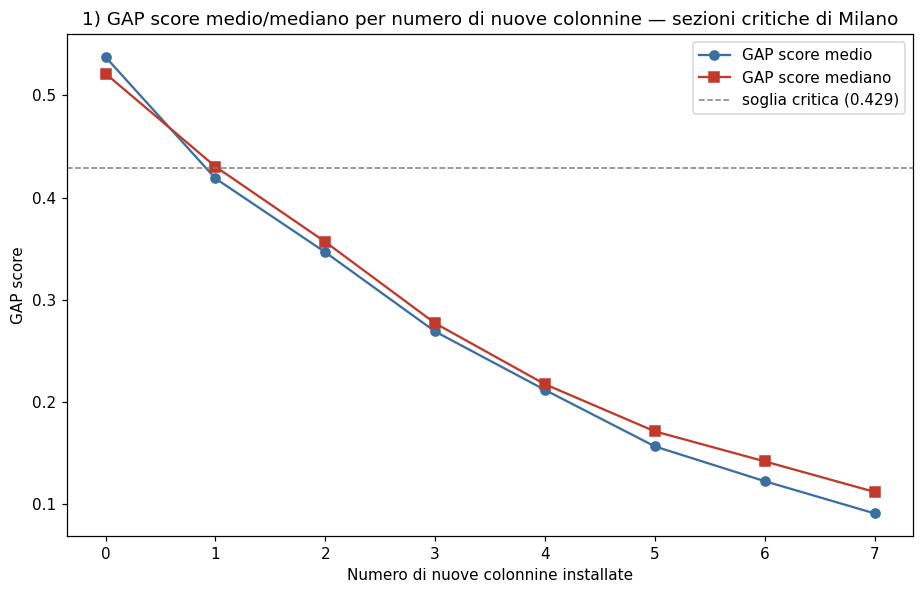

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(aggregati["nuove_colonnine"], aggregati["gap_score_medio"], marker="o", label="GAP score medio", color="#3b6fa0")
ax.plot(aggregati["nuove_colonnine"], aggregati["gap_score_mediano"], marker="s", label="GAP score mediano", color="#c0392b")
ax.axhline(SOGLIA_CRITICA, color="grey", linestyle="--", linewidth=1, label=f"soglia critica ({SOGLIA_CRITICA:.3f})")
ax.set_xlabel("Numero di nuove colonnine installate")
ax.set_ylabel("GAP score")
ax.set_title("1) GAP score medio/mediano per numero di nuove colonnine — sezioni critiche di Milano")
ax.legend()
plt.tight_layout()
plt.show()

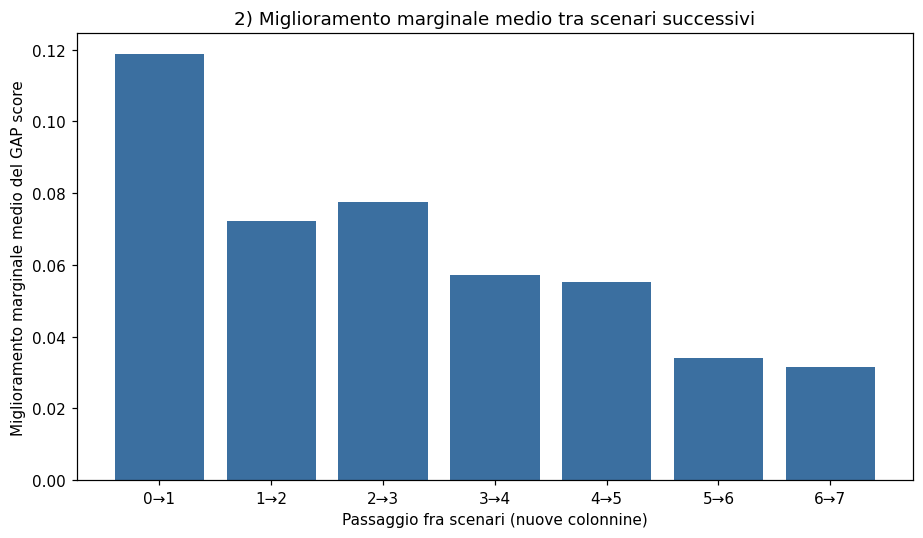

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5))
step_labels = [f"{prev}→{curr}" for prev, curr in zip([0] + SCENARI_NUOVE_COLONNINE[:-1], SCENARI_NUOVE_COLONNINE)][1:]
marg = aggregati.iloc[1:]
ax.bar(step_labels, marg["miglioramento_marginale_medio"], color="#3b6fa0")
ax.set_xlabel("Passaggio fra scenari (nuove colonnine)")
ax.set_ylabel("Miglioramento marginale medio del GAP score")
ax.set_title("2) Miglioramento marginale medio tra scenari successivi")
plt.tight_layout()
plt.show()

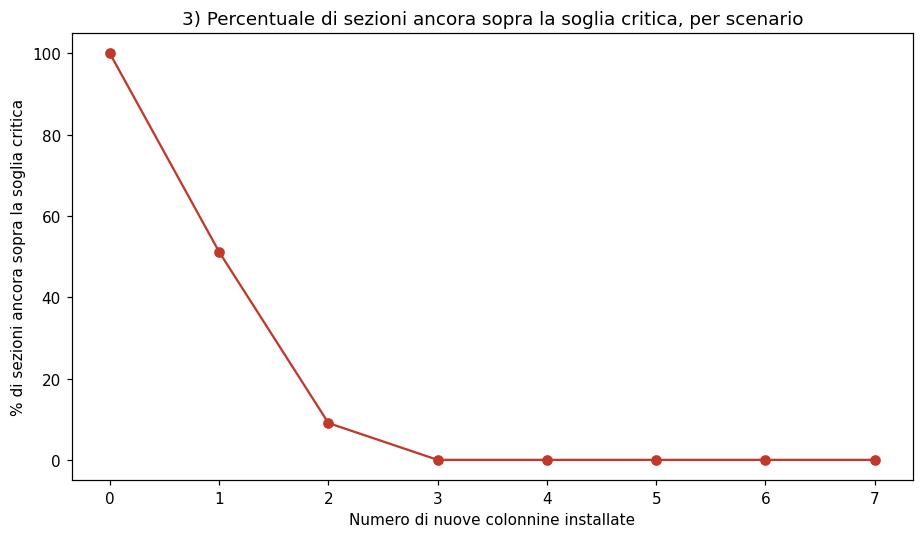

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(aggregati["nuove_colonnine"], aggregati["pct_sezioni_ancora_critiche"], marker="o", color="#c0392b")
ax.set_xlabel("Numero di nuove colonnine installate")
ax.set_ylabel("% di sezioni ancora sopra la soglia critica")
ax.set_title("3) Percentuale di sezioni ancora sopra la soglia critica, per scenario")
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

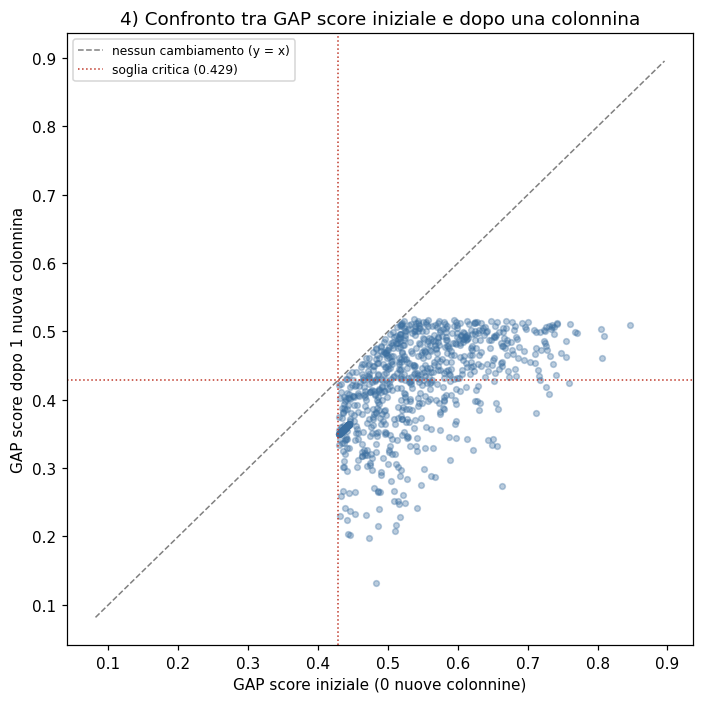

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
g0 = pivot_gap["gap_score_n0"]
g1 = pivot_gap["gap_score_n1"]
ax.scatter(g0, g1, alpha=0.35, s=14, color="#3b6fa0")
lim = [min(g0.min(), g1.min()) - 0.05, max(g0.max(), g1.max()) + 0.05]
ax.plot(lim, lim, color="grey", linestyle="--", linewidth=1, label="nessun cambiamento (y = x)")
ax.axhline(SOGLIA_CRITICA, color="#c0392b", linestyle=":", linewidth=1, label=f"soglia critica ({SOGLIA_CRITICA:.3f})")
ax.axvline(SOGLIA_CRITICA, color="#c0392b", linestyle=":", linewidth=1)
ax.set_xlabel("GAP score iniziale (0 nuove colonnine)")
ax.set_ylabel("GAP score dopo 1 nuova colonnina")
ax.set_title("4) Confronto tra GAP score iniziale e dopo una colonnina")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

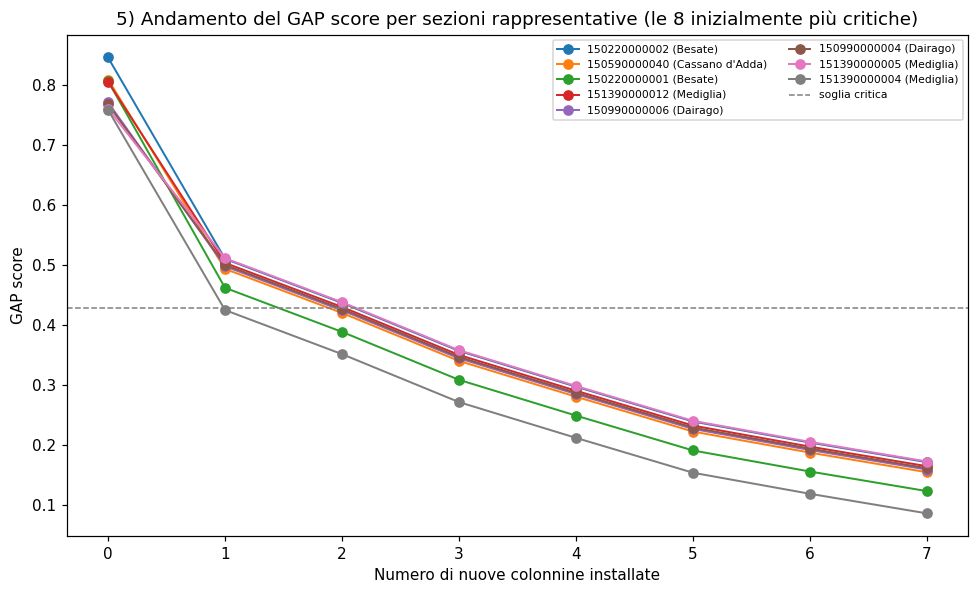

In [ ]:
# Sezioni rappresentative per l'andamento nel tempo: le 8 sezioni con gap_score
# iniziale piu' alto fra quelle analizzate.
sezioni_rappresentative = milano.nlargest(8, "gap_score")["SEZ2011"].tolist()
fig, ax = plt.subplots(figsize=(9, 5.5))
for sez in sezioni_rappresentative:
    traiettoria = sim[sim["SEZ2011"] == sez].sort_values("nuove_colonnine")
    comune = milano.loc[milano["SEZ2011"] == sez, "COMUNE"].iloc[0]
    ax.plot(traiettoria["nuove_colonnine"], traiettoria["gap_score_aggiornato"], marker="o",
            label=f"{sez} ({comune})", linewidth=1.3)
ax.axhline(SOGLIA_CRITICA, color="grey", linestyle="--", linewidth=1, label="soglia critica")
ax.set_xlabel("Numero di nuove colonnine installate")
ax.set_ylabel("GAP score")
ax.set_title("5) Andamento del GAP score per sezioni rappresentative (le 8 inizialmente più critiche)")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

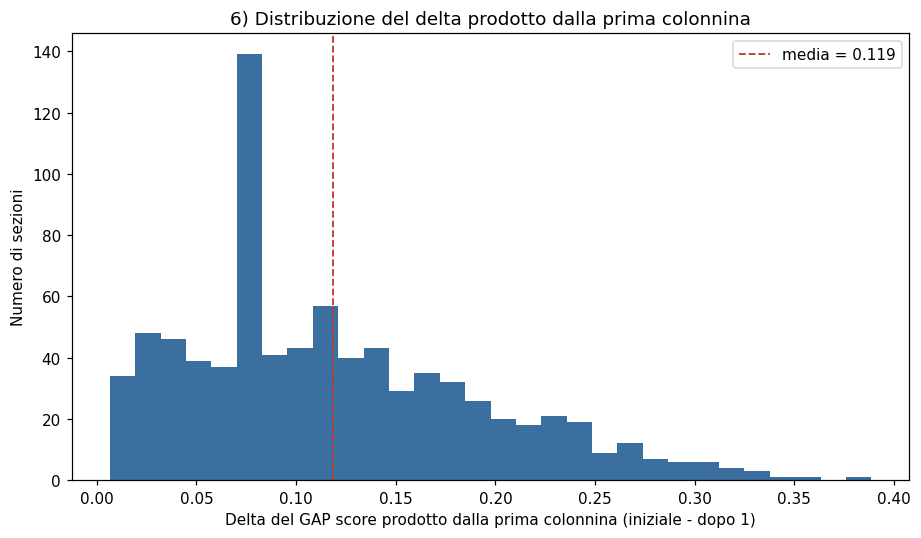

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5))
delta_1a = pivot_gap["gap_score_n0"] - pivot_gap["gap_score_n1"]
ax.hist(delta_1a, bins=30, color="#3b6fa0", edgecolor="none")
ax.axvline(delta_1a.mean(), color="#c0392b", linestyle="--", linewidth=1.2, label=f"media = {delta_1a.mean():.3f}")
ax.set_xlabel("Delta del GAP score prodotto dalla prima colonnina (iniziale - dopo 1)")
ax.set_ylabel("Numero di sezioni")
ax.set_title("6) Distribuzione del delta prodotto dalla prima colonnina")
ax.legend()
plt.tight_layout()
plt.show()

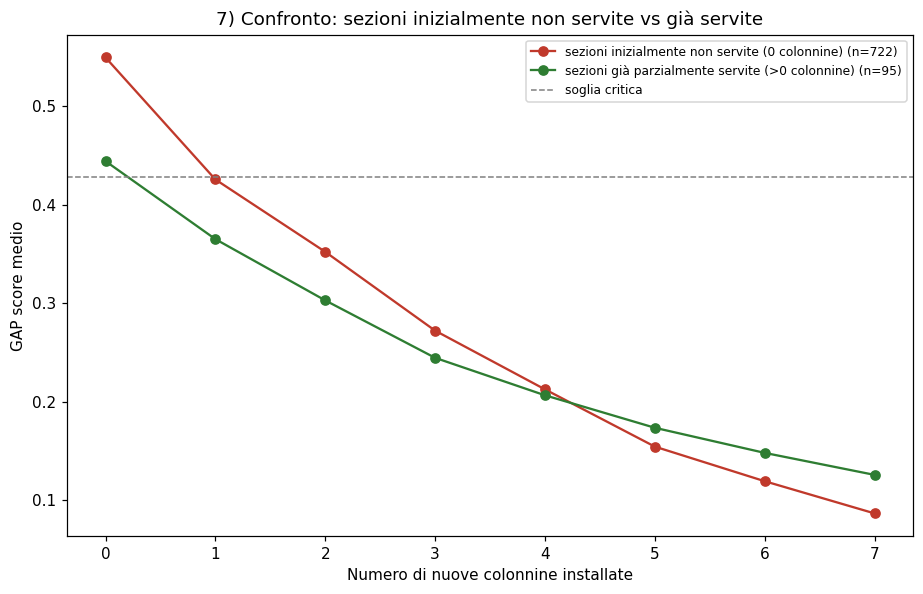

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
gia_servite = milano["offerta_colonnine_500m"] > 0
non_servite = ~gia_servite

for mask, etichetta, colore in [(non_servite, "sezioni inizialmente non servite (0 colonnine)", "#c0392b"),
                                 (gia_servite, "sezioni già parzialmente servite (>0 colonnine)", "#2e7d32")]:
    if mask.sum() == 0:
        continue
    medie = sim[sim["SEZ2011"].isin(milano.loc[mask, "SEZ2011"])].groupby("nuove_colonnine")["gap_score_aggiornato"].mean()
    ax.plot(medie.index, medie.values, marker="o", label=f"{etichetta} (n={mask.sum()})", color=colore)

ax.axhline(SOGLIA_CRITICA, color="grey", linestyle="--", linewidth=1, label="soglia critica")
ax.set_xlabel("Numero di nuove colonnine installate")
ax.set_ylabel("GAP score medio")
ax.set_title("7) Confronto: sezioni inizialmente non servite vs già servite")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 18. Tabelle finali

In [ ]:
print("Riepilogo dei risultati per scenario:")
aggregati.round(4)

Riepilogo dei risultati per scenario:


,nuove_colonnine,gap_score_medio,gap_score_mediano,riduzione_media,riduzione_mediana,n_sezioni_ancora_critiche,pct_sezioni_ancora_critiche,n_sezioni_scese_sotto_soglia,pct_sezioni_scese_sotto_soglia,miglioramento_marginale_medio,miglioramento_marginale_mediano,n_miglioramento_trascurabile
0,0,0.5374,0.5212,0.0000,0.0000,817.0,100.0000,0.0,0.0000,NaN,NaN,0.0
1,1,0.4187,0.4303,0.1187,0.1017,418.0,51.1628,399.0,48.8372,0.1187,0.1017,18.0
2,2,0.3465,0.3567,0.1909,0.1752,74.0,9.0575,743.0,90.9425,0.0722,0.0735,0.0
3,3,0.2690,0.2771,0.2684,0.2553,0.0,0.0000,817.0,100.0000,0.0775,0.0800,0.0
4,4,0.2119,0.2175,0.3255,0.3149,0.0,0.0000,817.0,100.0000,0.0571,0.0596,0.0
5,5,0.1567,0.1714,0.3807,0.3730,0.0,0.0000,817.0,100.0000,0.0552,0.0581,0.0
6,6,0.1227,0.1421,0.4147,0.4082,0.0,0.0000,817.0,100.0000,0.0340,0.0351,0.0
7,7,0.0912,0.1122,0.4462,0.4408,0.0,0.0000,817.0,100.0000,0.0315,0.0327,0.0


In [ ]:
scese_dopo_1a = sim[(sim["nuove_colonnine"] == 1) & (sim["scesa_sotto_soglia"])].merge(
    milano[["SEZ2011", "COMUNE"]], on="SEZ2011", how="left"
)
print(f"Sezioni che scendono sotto soglia già dopo la 1a colonnina: {len(scese_dopo_1a):,} / {len(milano):,}")
scese_dopo_1a[["SEZ2011", "COMUNE", "gap_score_iniziale", "gap_score_aggiornato", "delta_gap_score"]].sort_values(
    "delta_gap_score", ascending=False
).head(10).round(4)

Sezioni che scendono sotto soglia già dopo la 1a colonnina: 399 / 817


,SEZ2011,COMUNE,gap_score_iniziale,gap_score_aggiornato,delta_gap_score
242,151500000009,Morimondo,0.6629,0.2742,0.3886
264,151650000003,Ozzero,0.4836,0.1315,0.3521
180,151390000004,Mediglia,0.7586,0.4245,0.3341
179,151390000003,Mediglia,0.7112,0.3803,0.3309
144,151150000010,Lacchiarella,0.6557,0.3324,0.3234
112,150990000018,Dairago,0.7298,0.4090,0.3208
111,150990000017,Dairago,0.6484,0.3331,0.3153
178,151390000002,Mediglia,0.6509,0.3425,0.3084
177,151390000001,Mediglia,0.7264,0.4186,0.3078
4,150050000022,Albairate,0.5105,0.2086,0.3019


In [ ]:
ancora_critiche_7 = sim[(sim["nuove_colonnine"] == 7) & (sim["ancora_sopra_soglia"])].merge(
    milano[["SEZ2011", "COMUNE"]], on="SEZ2011", how="left"
)
print(f"Sezioni che restano critiche anche dopo 7 nuove colonnine: {len(ancora_critiche_7):,} / {len(milano):,}")
if len(ancora_critiche_7):
    ancora_critiche_7[["SEZ2011", "COMUNE", "gap_score_iniziale", "gap_score_aggiornato"]].round(4)
else:
    print("Nessuna sezione: in questo scenario tutte le sezioni critiche di Milano scendono sotto soglia entro 7 colonnine.")

Sezioni che restano critiche anche dopo 7 nuove colonnine: 0 / 817
Nessuna sezione: in questo scenario tutte le sezioni critiche di Milano scendono sotto soglia entro 7 colonnine.


In [ ]:
maggior_miglioramento = pivot_gap.copy()
maggior_miglioramento["riduzione_1a_colonnina"] = pivot_gap["gap_score_n0"] - pivot_gap["gap_score_n1"]
maggior_miglioramento = maggior_miglioramento.merge(milano[["SEZ2011", "COMUNE"]].set_index("SEZ2011"), left_index=True, right_index=True)

print("Sezioni con il maggiore miglioramento iniziale (1a colonnina):")
maggior_miglioramento.sort_values("riduzione_1a_colonnina", ascending=False).head(10)[
    ["COMUNE", "gap_score_n0", "gap_score_n1", "riduzione_1a_colonnina"]
].round(4)

Sezioni con il maggiore miglioramento iniziale (1a colonnina):


,COMUNE,gap_score_n0,gap_score_n1,riduzione_1a_colonnina
SEZ2011,,,,
151500000009,Morimondo,0.6629,0.2742,0.3886
151650000003,Ozzero,0.4836,0.1315,0.3521
150220000001,Besate,0.8066,0.4616,0.3450
150220000002,Besate,0.8458,0.5099,0.3359
151390000004,Mediglia,0.7586,0.4245,0.3341
151390000003,Mediglia,0.7112,0.3803,0.3309
151150000010,Lacchiarella,0.6557,0.3324,0.3234
150990000018,Dairago,0.7298,0.4090,0.3208
150590000040,Cassano d'Adda,0.8090,0.4932,0.3159


In [ ]:
minor_beneficio = pivot_gap.copy()
minor_beneficio["beneficio_marginale_1a_colonnina"] = pivot_gap["gap_score_n0"] - pivot_gap["gap_score_n1"]
minor_beneficio = minor_beneficio.merge(milano[["SEZ2011", "COMUNE", "offerta_colonnine_500m"]].set_index("SEZ2011"),
                                         left_index=True, right_index=True)

print("Sezioni con il minore beneficio marginale dopo la prima installazione:")
minor_beneficio.sort_values("beneficio_marginale_1a_colonnina", ascending=True).head(10)[
    ["COMUNE", "offerta_colonnine_500m", "gap_score_n0", "gap_score_n1", "beneficio_marginale_1a_colonnina"]
].round(4)

Sezioni con il minore beneficio marginale dopo la prima installazione:


,COMUNE,offerta_colonnine_500m,gap_score_n0,gap_score_n1,beneficio_marginale_1a_colonnina
SEZ2011,,,,,
152110000007,Settimo Milanese,0.0,0.5123,0.5058,0.0065
151660000027,Paderno Dugnano,0.0,0.5032,0.4960,0.0072
151660000026,Paderno Dugnano,0.0,0.4687,0.4615,0.0072
151820000322,Rho,0.0,0.4830,0.4757,0.0073
151460004975,Milano,0.0,0.5167,0.5093,0.0073
150700000035,Cernusco sul Naviglio,0.0,0.5226,0.5150,0.0076
151460003245,Milano,0.0,0.4444,0.4369,0.0076
151460004037,Milano,0.0,0.4297,0.4221,0.0077
151700000088,Pero,0.0,0.5190,0.5113,0.0077


## 19. Conclusioni

### Risultato nazionale

La classifica nazionale (sezione 6) è l'**output del modello**, non una misura
diretta della realtà: dipende dalla catena di stime e proxy descritta in
sezione 4 (disaggregazione dei veicoli elettrici a livello di sezione,
correzione per le flotte a noleggio, proxy di fattibilità di ricarica
domestica). Secondo il criterio di ordinamento adottato in questo notebook
(quota di sezioni critiche sul totale), **Catanzaro risulta la provincia più
critica d'Italia**; resta fra le primissime posizioni anche con l'indicatore
alternativo (quota di popolazione in sezioni critiche, sezione 4.3). Questo
risultato è coerente fra criteri diversi, il che è un elemento a suo favore, ma
resta **sensibile alla qualità delle proxy** che alimentano il GAP score e va
quindi **interpretato con cautela**: senza una validazione esterna (ad esempio
dati di immatricolazione locali o rilievi sul campo) non è possibile concludere
con certezza che Catanzaro sia realmente la provincia con il maggiore
fabbisogno di ricarica pubblica in Italia.

### Caso di studio di Milano

Milano è stata scelta come approfondimento operativo per ragioni indipendenti
dalla classifica nazionale (sezione 8), pur collocandosi in una posizione
bassa della classifica stessa (si veda il valore esatto in sezione 6). Sulle
817 sezioni critiche analizzate, con scenari da 1 a 7 nuove colonnine
installate una alla volta:

- la **prima colonnina produce la riduzione media più ampia** del GAP score fra
  tutti i passaggi da uno scenario al successivo (sezione 16), spiegabile dal
  fatto che quasi la metà delle sezioni eleggibili a livello nazionale non ha
  alcuna colonnina entro 500 m: uscire da questo gruppo comporta un salto di
  rango percentile molto maggiore di qualunque incremento successivo;
- il **beneficio marginale è complessivamente decrescente** lungo tutta la
  sequenza da 1 a 7 colonnine (0,119 → 0,072 → 0,078 → 0,057 → 0,055 → 0,034 →
  0,032 di riduzione media del GAP score ad ogni passaggio, sezione 15), pur
  **senza monotonia stretta a ogni singolo passaggio**: il beneficio della 3ª
  colonnina (0,078) risulta leggermente superiore a quello della 2ª (0,072),
  uno scostamento minore verosimilmente legato alla struttura non uniforme
  della distribuzione nazionale di `offerta_colonnine_500m` (sezione 16). Il
  calo complessivo resta comunque netto: dalla 1ª alla 7ª colonnina il
  beneficio marginale medio si riduce di circa il 73%;
- **in questo dataset nessuna sezione critica di Milano resta sopra la soglia
  del gomito già a partire da 3 nuove colonnine** (sezione 16): dopo la 1ª
  colonnina il 51,2% delle 817 sezioni (418) è ancora sopra soglia, dopo la 2ª
  il 9,1% (74), e dalla 3ª colonnina in avanti lo 0%. Questo risultato empirico
  **non conferma l'ipotesi di lavoro** secondo cui alcune sezioni potrebbero
  restare critiche a lungo anche dopo diverse installazioni, e va riportato
  come tale;
- questo risultato **non dimostra**, di per sé, quante colonnine bastino
  davvero nella realtà a risolvere il problema di una sezione: la simulazione
  modifica solo il conteggio di colonnine entro 500 m della singola sezione
  osservata (sezione 13) e ricalcola solo la componente di rango percentile del
  GAP score, lasciando invariata la domanda; un numero di colonnine sufficiente
  a far scendere il *rango* di una sezione sotto la soglia non equivale
  necessariamente, nella realtà, a un numero sufficiente a coprire la domanda
  fisica di ricarica di quell'area.

Questi risultati indicano che, per la porzione di sezioni critiche di Milano
analizzata, il GAP score — costruito come **differenza di ranghi
percentile nazionali** — è particolarmente sensibile al passaggio da "zero
colonnine" a "almeno una colonnina", e mostra un beneficio marginale via via
più contenuto (anche se non sempre rigorosamente monotono colonnina per
colonnina) man mano che le installazioni successive si accumulano da 1 a 7.

## 20. Testo pronto per una slide

In [ ]:
pos_cz = int(pos_catanzaro.iloc[0])
pos_mi = int(pos_milano.iloc[0])
riduzione_1a_pct = 100 * primo_delta.mean() / milano["gap_score"].mean()

if n_ancora_dopo_7 == 0:
    frase_esito = "in questo campione tutte le sezioni scendono sotto la soglia critica entro 7 nuove colonnine"
else:
    frase_esito = (f"in questo campione {n_ancora_dopo_7:,} sezioni su {len(milano):,} "
                    f"({100 * n_ancora_dopo_7 / len(milano):.1f}%) restano sopra la soglia critica anche dopo 7 nuove colonnine")

testo_slide = f'''Il modello individua le province con la maggiore criticità teorica secondo il GAP score: Catanzaro si colloca in {pos_cz}ª posizione su {n_prov_tot} (quota di sezioni critiche: {prov.loc[prov["PROVINCIA"]=="Catanzaro","quota_sezioni_critiche_pct"].iloc[0]:.1f}%).
Questa graduatoria deve essere interpretata con cautela, perché deriva dalla combinazione di dati osservati, stime territoriali e più variabili proxy (correzione flotte, fattibilità di ricarica domestica) le cui incertezze si accumulano lungo la pipeline.
Per l'analisi operativa è stata scelta Milano ({pos_mi}ª posizione su {n_prov_tot}), un contesto in cui la domanda di mobilità elettrica risulta plausibilmente elevata e i risultati sono interpretativamente più solidi grazie all'ampia numerosità di sezioni.
La simulazione su {len(milano):,} sezioni critiche di Milano, con installazioni progressive da 1 a 7 nuove colonnine, mostra che la prima nuova colonnina produce il miglioramento medio più rilevante del GAP score (riduzione media {primo_delta.mean():.3f}, pari al {riduzione_1a_pct:.0f}% del GAP score medio iniziale), mentre le installazioni successive hanno un beneficio marginale via via più contenuto; {frase_esito}.
Il limite metodologico principale è che il GAP score misura un rango percentile nazionale, non un bisogno fisico di ricarica: superare la soglia in rango non equivale automaticamente a soddisfare la domanda reale di quell'area, e la simulazione non tiene conto dell'effetto di una nuova colonnina sulle sezioni confinanti.'''

print(testo_slide)

Il modello individua le province con la maggiore criticità teorica secondo il GAP score: Catanzaro si colloca in 1ª posizione su 110 (quota di sezioni critiche: 24.1%).
Questa graduatoria deve essere interpretata con cautela, perché deriva dalla combinazione di dati osservati, stime territoriali e più variabili proxy (correzione flotte, fattibilità di ricarica domestica) le cui incertezze si accumulano lungo la pipeline.
Per l'analisi operativa è stata scelta Milano (72ª posizione su 110), un contesto in cui la domanda di mobilità elettrica risulta plausibilmente elevata e i risultati sono interpretativamente più solidi grazie all'ampia numerosità di sezioni.
La simulazione su 817 sezioni critiche di Milano, con installazioni progressive da 1 a 7 nuove colonnine, mostra che la prima nuova colonnina produce il miglioramento medio più rilevante del GAP score (riduzione media 0.119, pari al 22% del GAP score medio iniziale), mentre le installazioni successive hanno un beneficio marginale 

## 21. Controlli finali

In [ ]:
anomalie = []

# 1) Nessun valore infinito nelle colonne numeriche della simulazione.
colonne_numeriche = sim.select_dtypes(include=[np.number]).columns
n_inf = np.isinf(sim[colonne_numeriche]).sum().sum()
print(f"1) Valori infiniti nella tabella di simulazione: {n_inf}")
if n_inf:
    anomalie.append(f"{n_inf} valori infiniti trovati in 'sim'")

# 2) Valori mancanti attesi vs inattesi.
mancanti_attesi = sim["delta_gap_score_percentuale"].isna().sum()  # solo se gap_score_iniziale ~ 0
mancanti_marginale = sim["miglioramento_marginale"].isna().sum()   # solo allo scenario 0 (nessun precedente)
print(f"2) Valori mancanti in 'delta_gap_score_percentuale': {mancanti_attesi} (attesi solo per gap_score_iniziale ~ 0)")
print(f"   Valori mancanti in 'miglioramento_marginale': {mancanti_marginale} (attesi: {milano.shape[0]}, uno per sezione, allo scenario 0 iniziale)")
if mancanti_marginale != len(milano):
    anomalie.append("numero di NaN in 'miglioramento_marginale' diverso dal numero atteso di sezioni")

# 3) Corrispondenza fra gap_score originale e scenario iniziale (0 nuove colonnine).
gap_scenario0 = sim.loc[sim["nuove_colonnine"] == 0].set_index("SEZ2011")["gap_score_aggiornato"]
gap_originale = milano.set_index("SEZ2011")["gap_score"]
scarto = (gap_scenario0 - gap_originale).abs().max()
print(f"3) Scarto massimo fra gap_score originale e scenario 0 ricalcolato: {scarto:.2e}")
if scarto > 1e-6:
    anomalie.append(f"scarto scenario 0 superiore alla tolleranza: {scarto:.2e}")

# 4) L'aumento dell'offerta non deve peggiorare il GAP score (dato il segno della formula).
peggioramenti = sim.groupby("SEZ2011").apply(
    lambda g: (g.sort_values("nuove_colonnine")["gap_score_aggiornato"].diff().dropna() > 1e-9).any(),
    include_groups=False,
)
n_peggioramenti = int(peggioramenti.sum())
print(f"4) Sezioni in cui il GAP score aumenta (peggiora) nonostante più colonnine: {n_peggioramenti}")
if n_peggioramenti:
    anomalie.append(f"{n_peggioramenti} sezioni mostrano un peggioramento del GAP score con più offerta")

# 5) Monotonia decrescente del GAP score medio all'aumentare delle colonnine (su larga scala).
monotona = aggregati["gap_score_medio"].is_monotonic_decreasing
print(f"5) GAP score medio decrescente su tutti gli scenari (0->1->2->3->4->5->6->7): {monotona}")

print()
if anomalie:
    print("ANOMALIE RILEVATE:")
    for a in anomalie:
        print(" -", a)
else:
    print("Nessuna anomalia rilevata nei controlli automatici sopra.")

print()
print("Riepilogo file sorgente utilizzati (nessuno modificato o sovrascritto):")
for chiave, percorso in PERCORSI.items():
    if percorso is not None:
        print(f"  - {chiave}: {percorso}")

print()
print("Assunzioni e limiti metodologici principali:")
print('''  1. Criterio di classifica nazionale: quota di sezioni critiche sul totale
     (Mediana_GAP_Score_per_Provincia.ipynb), per esplicita indicazione dell'autore
     dell'analisi. L'indicatore alternativo piu' recente (quota di popolazione in
     sezioni critiche, Ranking_Province_GAP_Score.ipynb) resta documentato e
     mostrato in tabella, ma non e' quello usato per ordinare la classifica.
  2. La domanda_norm per sezione e' ricavata algebricamente dal gap_score originale e
     dall'offerta_norm iniziale ricalcolata (non dalle componenti intermedie della
     domanda, non disponibili a livello di singola sezione in questo notebook).
  3. Il riferimento nazionale per il ricalcolo di offerta_norm resta fisso ai valori
     iniziali (346.507 sezioni eleggibili) per tutti gli scenari, cosi' come richiesto
     per la confrontabilita' fra scenari.
  4. La simulazione modifica il conteggio di colonnine solo per la sezione osservata:
     non modella l'effetto di una nuova colonnina sulle sezioni confinanti (limite
     dichiarato in sezione 13).
  5. Il superamento della soglia in rango percentile non equivale a una copertura
     fisica della domanda di ricarica reale (sezione 19).
  6. Gli scenari simulati sono 0 (baseline) e da 1 a 7 nuove colonnine, installate
     una alla volta sulla stessa sezione (non piu' i salti piu' ampi a 10/30 colonnine
     usati in una versione precedente di questo notebook).''')

1) Valori infiniti nella tabella di simulazione: 0
2) Valori mancanti in 'delta_gap_score_percentuale': 0 (attesi solo per gap_score_iniziale ~ 0)
   Valori mancanti in 'miglioramento_marginale': 817 (attesi: 817, uno per sezione, allo scenario 0 iniziale)
3) Scarto massimo fra gap_score originale e scenario 0 ricalcolato: 5.55e-17


4) Sezioni in cui il GAP score aumenta (peggiora) nonostante più colonnine: 0
5) GAP score medio decrescente su tutti gli scenari (0->1->2->3->4->5->6->7): True

Nessuna anomalia rilevata nei controlli automatici sopra.

Riepilogo file sorgente utilizzati (nessuno modificato o sovrascritto):
  - gap_score_nazionale: E:\project\dati\gap_score_definitivo.csv
  - anagrafica_sezioni: E:\project\sezioni_censimento_2011_ridotto.csv
  - offerta_colonnine: E:\project\dati\offerta_colonnine_per_sezione.parquet
  - sezioni_critiche_milano: E:\project\dati\sezioni_critiche_milano.csv
  - ranking_province_precomputato: E:\project\output_idi\ranking_province_gap_score.csv
  - sezioni_critiche_catanzaro: E:\project\output_idi\sezioni_critiche_catanzaro.csv

Assunzioni e limiti metodologici principali:
  1. Criterio di classifica nazionale: quota di sezioni critiche sul totale
     (Mediana_GAP_Score_per_Provincia.ipynb), per esplicita indicazione dell'autore
     dell'analisi. L'indicatore alternati